In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy import stats
import pandas as pd
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict
from scipy.optimize import curve_fit

# Load simulation outputs

In [35]:
files = os.listdir("../toy/output/")
#print(files)

outputs = ["toy/output/" + item for item in files if "0p0g.npz" in item]
outputs_g =["toy/output/" + item for item in files if "monocromatic" in item]
#print(outputs)

simulation_list   = {}
monocromatic_list = {}

for output in outputs:
    #print(output)
    if not "monocromatic" in output:
        filename   = output.split("/")[2]
        tau        = output.split("_")[1].replace("s","")
        theta      = output.split("_")[3]
        axial      = output.split("_")[5].replace("mK","")
        transverse = output.split("_")[7].replace("mK","")
        append_to_dict(simulation_list, output, float(tau))
        append_to_dict(simulation_list, output, float(theta))
        append_to_dict(simulation_list, output, float(axial))
        append_to_dict(simulation_list, output, float(transverse))

trial = set()
for output in outputs_g:
    if "monocromatic" in output:
        print(output)
        filename = output.split("/")[2]
        tau        = output.split("_")[2].replace("s","")
        theta      = output.split("_")[4]
        axial      = output.split("_")[6].replace("mK","")
        transverse = output.split("_")[8].replace("mK","")
        append_to_dict(monocromatic_list, output, float(tau))
        append_to_dict(monocromatic_list, output, float(theta))
        append_to_dict(monocromatic_list, output, float(axial))
        append_to_dict(monocromatic_list, output, float(transverse))
        trial.add("_".join(output.split("/")[2].split("_")[:-1]))





toy/output/monocromatic_tau_99999999.00s_theta_0_axial_0.50mK_transv_0.10mK_-10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_0.10mK_transv_0.10mK_-10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_1.00mK_transv_5.00mK_-10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_1.00mK_transv_1.00mK_0p5g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_1.00mK_transv_10.00mK_10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_15.00mK_transv_10.00mK_-0p5g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_5.00mK_transv_1.00mK_-10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_1.00mK_transv_10.00mK_-0p5g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_1.00mK_transv_1.00mK_-0p5g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_0.01mK_transv_0.01mK_-10p0g.npz
toy/output/monocromatic_tau_99999999.00s_theta_0_axial_0.10mK_transv_0.50mK_0p5g.npz
toy/output/monocromatic_tau_99999999.00s_theta_

In [6]:
print("Tot. Trials %d" % len(simulation_list.items()))

Tot. Trials 94


## Z cuts in 2025 dataset

In [25]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

# Define the analysis functions for data and simulation

In [26]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)] # delete atoms that are still trapped, identified with 'nan'
    counts, edges     = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

# Main Loop LR statitics and visualization

In [27]:
!ls

Comparison.ipynb
README.txt
data_onlyramp.txt
data_onlywait.txt
simulation_results.png
tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK__Scurve.png
tau_100000.00s_theta_0_axial_12.07mK_transv_9.99mK__Scurve_seg3.png
tau_100000.00s_theta_0_axial_13.66mK_transv_1.74mK__Scurve.png
tau_100000.00s_theta_0_axial_13.66mK_transv_1.74mK__Scurve_seg3.png
tau_100000.00s_theta_0_axial_19.16mK_transv_7.27mK__Scurve.png
tau_100000.00s_theta_0_axial_19.16mK_transv_7.27mK__Scurve_seg3.png
tau_100000.00s_theta_0_axial_5.92mK_transv_5.11mK__Scurve.png
tau_100000.00s_theta_0_axial_5.92mK_transv_5.11mK__Scurve_seg3.png
tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK__Scurve.png
tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK__Scurve_seg3.png
tau_2.35s_theta_140_axial_5.79mK_transv_10.38mK__Scurve.png
tau_25.81s_theta_113_axial_4.92mK_transv_19.44mK__Scurve.png
tau_30.27s_theta_105_axial_16.62mK_transv_19.38mK__Scurve.png
tau_6.21s_theta_15_axial_1.03mK_transv_3.12mK__Scurve.png
tau_62.18s_theta_61_axial

## Load and analyze gravity runs

In [28]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

stringa          = ""

dict_runs = {}
for dataset in list_dataset:
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    append_to_dict(dict_runs, dataset, counts_obs)

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

## Load the simulation output and get the data

In [29]:
for file in outputs:
    if("0p0g" in file):
        data = np.load("../" + file)
        LR_total = data['metric']
        
        try:
            Chisq    = data['Chisq_S']
            print(f"loading {file}  {LR_total}  {Chisq}")
            append_to_dict(simulation_list, file, float(LR_total))
            append_to_dict(simulation_list, file, Chisq[0])
            append_to_dict(simulation_list, file, Chisq[1])
            append_to_dict(simulation_list, file, Chisq[2])
            append_to_dict(simulation_list, file, Chisq[3])
        except:
            print("Chisq not in archive, skip")
            simulation_list.pop(file, None)
        
        print("-"*16)


loading toy/output/tau_28.58s_theta_129_axial_14.85mK_transv_11.65mK_0p0g.npz  9999999  [   196.65108666  19610.01586271 104355.67042355  72425.72207684]
----------------
loading toy/output/tau_62.00s_theta_1_axial_13.94mK_transv_9.86mK_0p0g.npz  9999999  [213.1490655   70.79165978 202.46166175 103.83762212]
----------------
loading toy/output/tau_92.94s_theta_45_axial_13.89mK_transv_14.98mK_0p0g.npz  4215.442325701726  [  178.73145177  6873.92919446 99910.0984618  51332.05239545]
----------------
loading toy/output/tau_95.26s_theta_34_axial_11.15mK_transv_11.46mK_0p0g.npz  3681.0695281221165  [   184.81446751   1730.46057567 107308.58915137  43849.37777341]
----------------
loading toy/output/tau_64.76s_theta_28_axial_14.96mK_transv_4.36mK_0p0g.npz  3010.8647100319486  [  194.08783992   907.187014   79560.98914345 36458.85272597]
----------------
loading toy/output/tau_28.12s_theta_37_axial_17.41mK_transv_7.01mK_0p0g.npz  3438.952698786071  [  162.534439    8124.08395348 88296.9414205

## List best simulation

In [30]:
best_for_dataset = ""
print("-"*15)
print("BEST TIME DISTRIBUTIONS")
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][4])[:3]:
    print(f"{k}: LR = {v[4]:.0f}")
    best_for_dataset = k
print("-"*15)
print("BEST CHISQ SEG 2")
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][5])[:3]:
    print(f"{k}: Chisq = {v[5]:.0f}")
print("-"*15)
print("BEST CHISQ SEG 3")
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][6])[:3]:
    print(f"{k}: Chisq = {v[6]:.0f}")
print("-"*15)
print("BEST CHISQ SEG 2 boiloff")
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][7])[:3]:
    print(f"{k}: Chisq = {v[7]:.0f}")
print("-"*15)
print("BEST CHISQ SEG 3 boiloff")
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][8])[:3]:
    print(f"{k}: Chisq = {v[8]:.0f}")

print(best_for_dataset)

# Overwrite best_for_dataset
#best_for_dataset = "toy/output/tau_74.10s_theta_171_axial_10.15mK_transv_11.89mK_0p0g.npz"

---------------
BEST TIME DISTRIBUTIONS
toy/output/tau_143.35s_theta_175_axial_0.51mK_transv_16.72mK_0p0g.npz: LR = 1605
toy/output/tau_109.48s_theta_94_axial_10.04mK_transv_2.09mK_0p0g.npz: LR = 1918
toy/output/tau_21.72s_theta_82_axial_20.65mK_transv_1.01mK_0p0g.npz: LR = 1965
---------------
BEST CHISQ SEG 2
toy/output/tau_90.21s_theta_116_axial_1.38mK_transv_11.05mK_0p0g.npz: Chisq = 154
toy/output/tau_54.43s_theta_59_axial_24.66mK_transv_17.66mK_0p0g.npz: Chisq = 156
toy/output/tau_28.12s_theta_37_axial_17.41mK_transv_7.01mK_0p0g.npz: Chisq = 163
---------------
BEST CHISQ SEG 3
toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_0p0g.npz: Chisq = 65
toy/output/tau_78.52s_theta_1_axial_13.30mK_transv_9.01mK_0p0g.npz: Chisq = 66
toy/output/tau_50.99s_theta_2_axial_10.47mK_transv_4.41mK_0p0g.npz: Chisq = 66
---------------
BEST CHISQ SEG 2 boiloff
toy/output/tau_37.24s_theta_0_axial_18.84mK_transv_10.65mK_0p0g.npz: Chisq = 196
toy/output/tau_62.00s_theta_1_axial_13.94mK_trans

## Plot time distributions

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

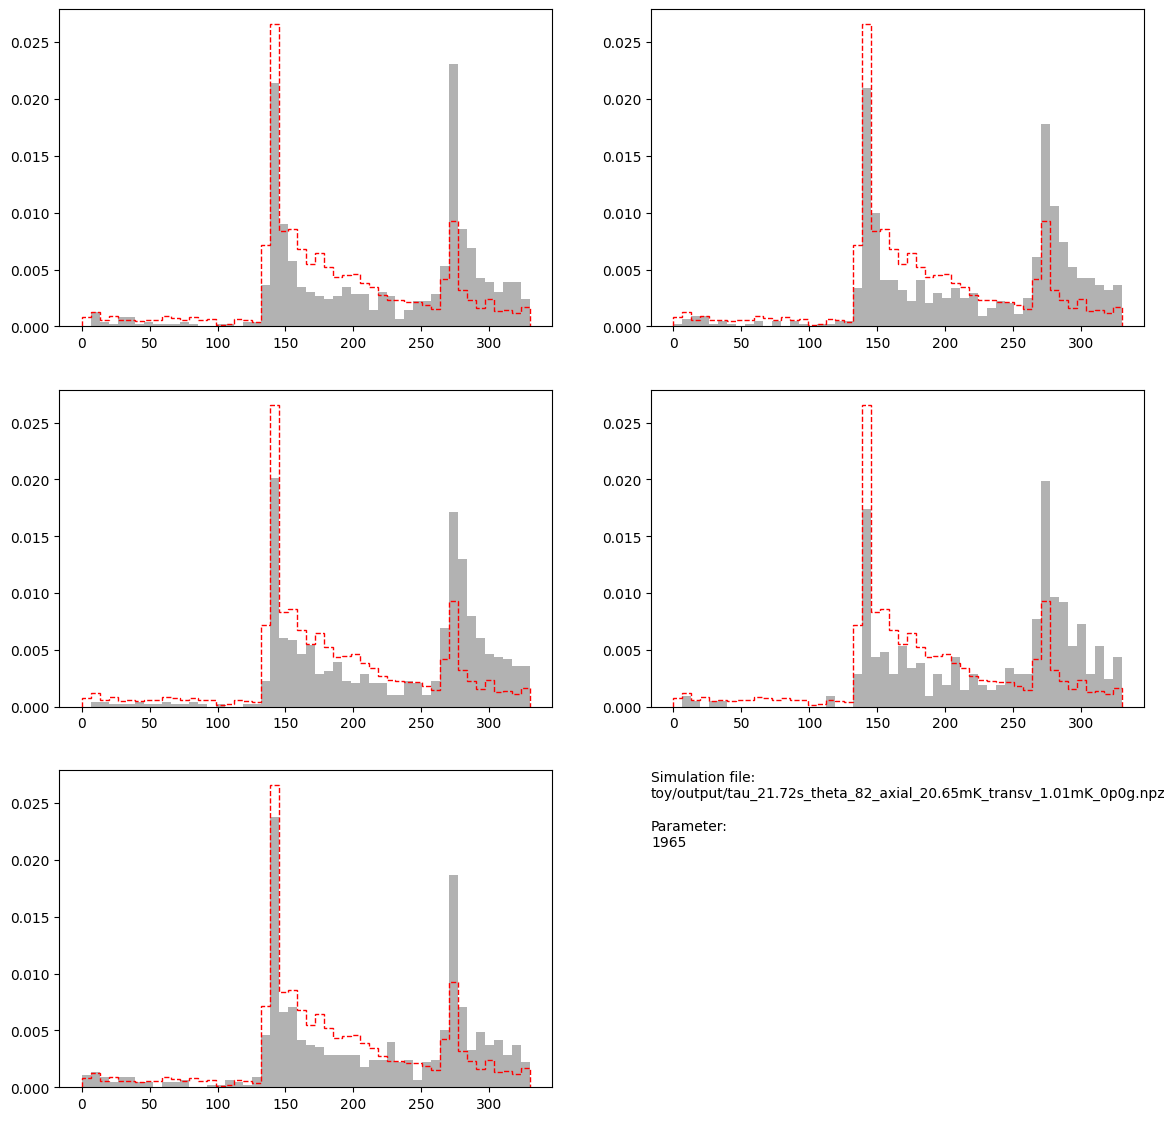

In [10]:
plt.figure(0, figsize=(14,14))

i = 1
for dataset in list_dataset:
    simulation = best_for_dataset
    ax         = plt.subplot(3, 2, i)
    i += 1

    Time_Simulation, counts, edges = analysis_function("../" + simulation)
    Event_Distribution, counts, edges = analysis_data("../" + dataset, ZCUTS)

    ax.hist(Event_Distribution, bins=50, range=(0,330), density=True,
            color="black", alpha=.3)

    ax.hist(Time_Simulation, bins=50, range=(0,330), density=True,
            linestyle="--", histtype="step", color="red")

# ---- ultimo subplot SOLO TESTO ----
ax_text = plt.subplot(3, 2, 6)
ax_text.axis("off")   # niente assi

text = (
    f"Simulation file:\n"
    f"{simulation}\n\n"
    f"Parameter:\n"
    f"{simulation_list[best_for_dataset][4]:.0f}"
)

ax_text.text(
    0.0, 1.0, text,
    transform=ax_text.transAxes,
    fontsize=10,
    verticalalignment="top"
)

plt.savefig("simulation_results.png", bbox_inches="tight")

# Analysis Mono-cromatic simulation

In [20]:
def load_simulation(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    return R_array, Time_Annihilation

def get_annihilations(output, bias):
    f = np.load(output)
    R = f["position"]
    t = f["Time"]

    m = np.isfinite(t)
    z = R[m, 2]
    t = t[m]

    z_up   = zacceptance_max - 1e-3
    z_down = zacceptance_min + 1e-3

    def counts(tmin=None, tmax=None):
        mt = np.ones_like(t, dtype=bool)
        if tmin is not None: mt &= (t > tmin)
        if tmax is not None: mt &= (t < tmax)
        nup   = np.sum((z >= z_up)   & mt)
        ndown = np.sum((z <= z_down) & mt)
        return nup, ndown

    def asym(nup, ndown):
        n = nup + ndown
        if n == 0:
            return np.nan, np.nan
        A = (ndown - nup) / n
        dA = np.sqrt(np.abs(1 - A**2) / n)
        return A, dA

    # totale (t finito)
    A, dA = asym(*counts())

    # segmenti: (tmin, tmax)
    windows = {
        "A0":  (0,        Tramp1),
        "A0b": (Tramp1,   wait_ramp1),
        "A1":  (wait_ramp1, Tramp2),
        "A1b": (Tramp2,   wait_ramp2),
        "A2":  (wait_ramp2, Tramp3),
        "A2b": (Tramp3,   None),
    }

    (A0, dA0)   = asym(*counts(*windows["A0"]))
    (A0b, dA0b) = asym(*counts(*windows["A0b"]))
    (A1, dA1)   = asym(*counts(*windows["A1"]))
    (A1b, dA1b) = asym(*counts(*windows["A1b"]))
    (A2, dA2)   = asym(*counts(*windows["A2"]))
    (A2b, dA2b) = asym(*counts(*windows["A2b"]))

    return [A0, A1, A2, A, A0b, A1b, A2b], [dA0, dA1, dA2, dA, dA0b, dA1b, dA2b]
    

In [39]:
monocromatic_dict = {}

biases = []
for key, value in monocromatic_list.items():
    #print(key, value[2], value[3])
    R_array, Time_Annihilation = load_simulation("../" + key)
    bias = key.split("_")[9].replace(".npz","")
    #print(bias)
    biases.append( float( bias.replace("p",".").replace("g","") ))
    print(bias, value[2], value[3] , Time_Annihilation)

    # plt.hist(Time_Annihilation, bins=50, range=(0,330), density=True,
    #         linestyle="--", histtype="step", label = f"{key}")

for ind, tmp in enumerate(trial):
    # get the biases simulated
    print(tmp)
    list_biases = [item for item in outputs_g if tmp in item]
    print(list_biases)
    #get_annihilations()
#plt.legend()

-10p0g 0.5 0.1 [140.3097 140.4099 140.4122 140.3322 140.462  140.3393 140.5193 140.3316
 140.403  140.3537 140.4596 140.4848 140.3461 140.4505 140.5221 140.3938
 140.3942 140.5839 140.4252 140.4671 140.3354 140.4538 140.401  140.3197
 140.3452 140.4912 140.4241 140.2776 140.3483 140.5071 140.4363 140.5717
 140.3397 140.4734 140.4827 140.4085 140.4602 140.5061 140.4431 140.2957
 140.4651 140.3459 140.4744 140.4503 140.5164 140.4555 140.329  140.427
 140.4871 140.3193 140.4456 140.3229 140.5345 140.3821 140.4292 140.3866
 140.4315 140.4325 140.4574 140.4893 140.4047 140.45   140.4835 140.4213
 140.3643 140.4408 140.5171 140.5523 140.4632 140.4533 140.3145 140.2369
 140.572  140.4354 140.5602 140.3923 140.4582 140.3977 140.4578 140.3954
 140.3779 140.3657 140.3976 140.3232 140.5177 140.4444 140.3685 140.5427
 140.2884 140.4003 140.4451 140.4811 140.4918 140.3358 140.3157 140.5815
 140.3912 140.4345 140.3576 140.4886]
-10p0g 0.1 0.1 [140.3058 140.3959 140.4072 140.3388 140.4125 140.4369 14

## Heatmap

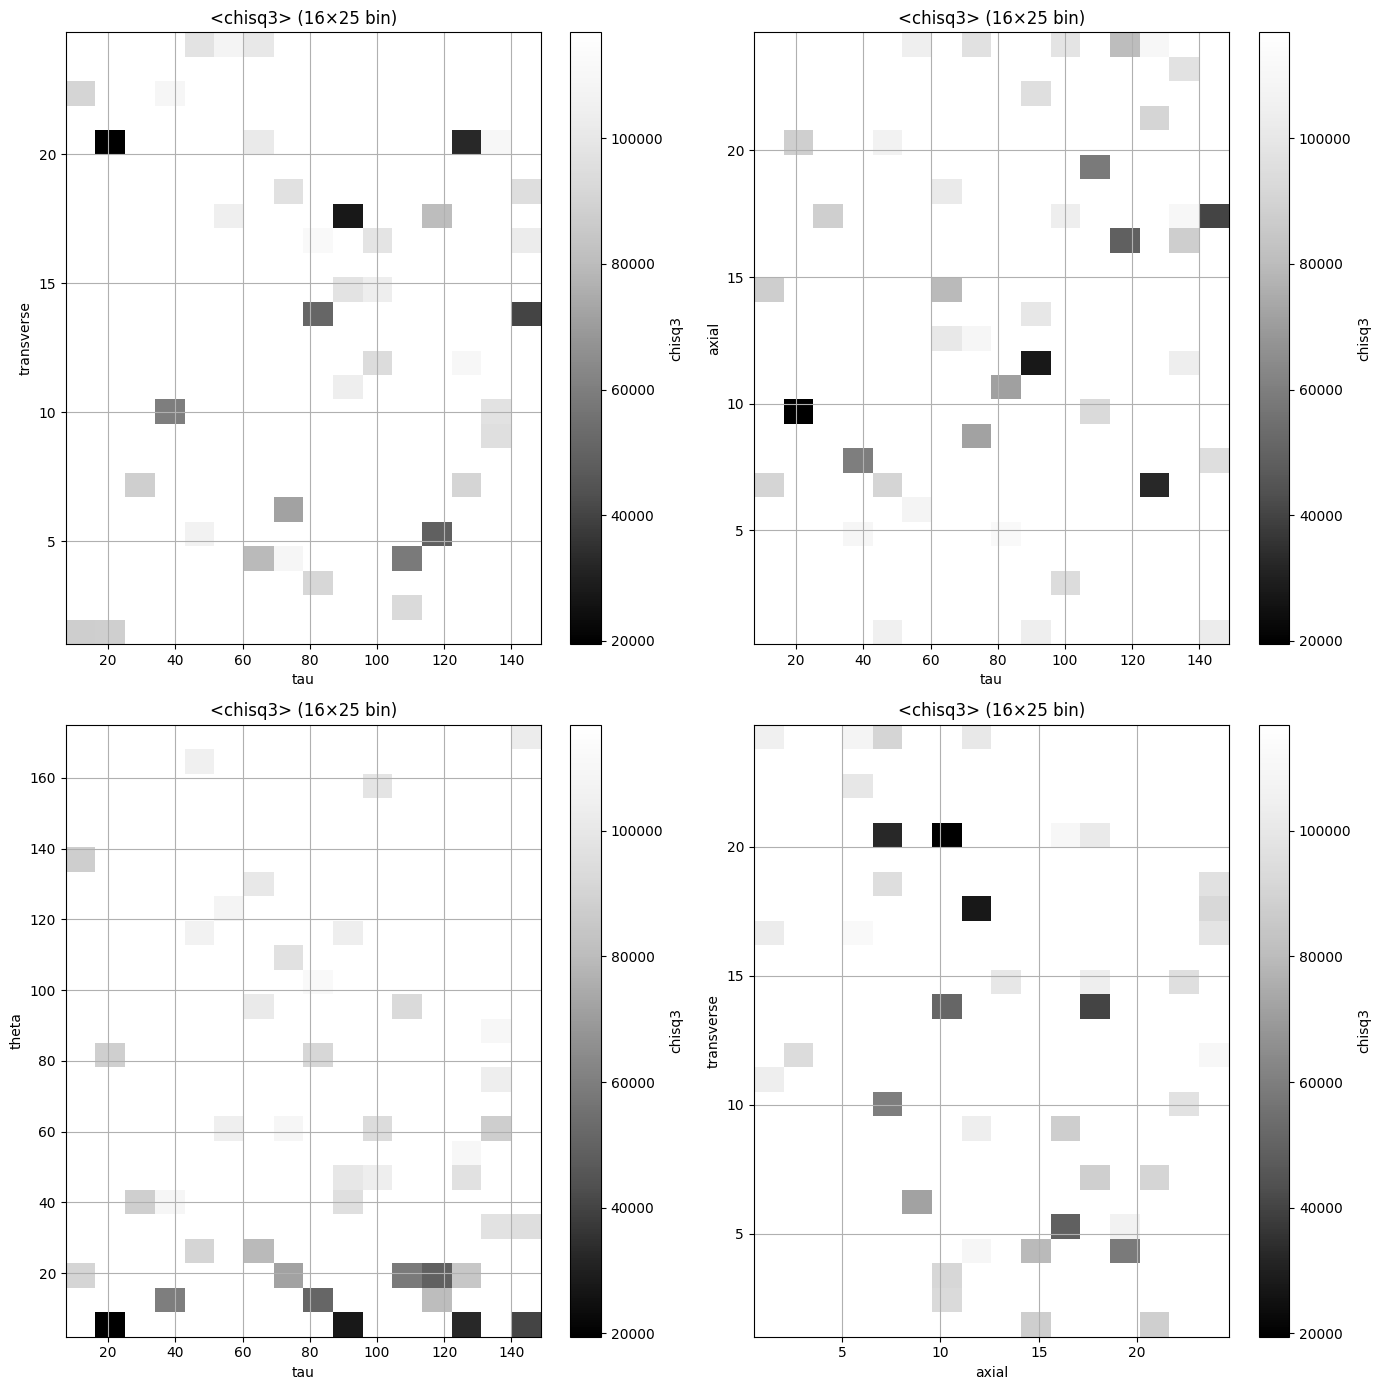

In [11]:
Metric = "chisq3"

df = pd.DataFrame.from_dict(simulation_list, orient='index',
                            columns=["tau", "theta", "axial", "transverse", "LR", "chisq1", "chisq2", "chisq3", "chisq4"])


# Filtra il DataFrame per tau tra 0 e 40
df = df[(df["tau"] >= 0) & (df["tau"] <= 200) & (df["LR"] <= 99999)]

# Crea figura con 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 14))


# Lista delle coppie di parametri da plottare
param_pairs = [
    ("tau", "transverse"),
    ("tau", "axial"),
    ("tau", "theta"),
    ("axial",   "transverse")
]

for i, (x_param, y_param) in enumerate(param_pairs):
    ax = axes[i // 2, i % 2]

    # estrai dati e rimuovi NaN
    mask = (
        np.isfinite(df[x_param]) &
        np.isfinite(df[y_param]) &
        np.isfinite(df[Metric])
    )

    x = df.loc[mask, x_param].values
    y = df.loc[mask, y_param].values
    z = df.loc[mask, Metric].values

    # range fissi
    x_range = (x.min(), x.max())
    y_range = (y.min(), y.max())

    # binning
    LR_sum, xedges, yedges = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range],
        weights=z
    )

    counts, _, _ = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range]
    )

    # FIX: inizializza LR_mean
    LR_mean = np.full_like(LR_sum, np.nan, dtype=float)
    
    LR_mean[counts != 0] = LR_sum[counts != 0] / counts[counts != 0] #print(LR_mean)
    pcm = ax.pcolormesh(
        xedges,
        yedges,
        LR_mean.T,
        cmap="Greys_r",
        shading="auto"
    )

    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title(f"<{Metric}> (16×25 bin)")
    ax.grid(True)

    fig.colorbar(pcm, ax=ax, label=Metric)

#axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


# ===> ANALYZE SCURVE

In [12]:
from toy.UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [13]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [14]:
# Make Plot Nicer
def plotter_nicer():
    plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
    plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    #plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

In [15]:
def get_annihilations(output, bias):
    f = np.load(output)
    R = f["position"]
    t = f["Time"]

    m = np.isfinite(t)
    z = R[m, 2]
    t = t[m]

    z_up   = zacceptance_max - 1e-3
    z_down = zacceptance_min + 1e-3

    def counts(tmin=None, tmax=None):
        mt = np.ones_like(t, dtype=bool)
        if tmin is not None: mt &= (t > tmin)
        if tmax is not None: mt &= (t < tmax)
        nup   = np.sum((z >= z_up)   & mt)
        ndown = np.sum((z <= z_down) & mt)
        return nup, ndown

    def asym(nup, ndown):
        n = nup + ndown
        if n == 0:
            return np.nan, np.nan
        A = (ndown - nup) / n
        dA = np.sqrt(np.abs(1 - A**2) / n)
        return A, dA

    # totale (t finito)
    A, dA = asym(*counts())

    # segmenti: (tmin, tmax)
    windows = {
        "A0":  (0,        Tramp1),
        "A0b": (Tramp1,   wait_ramp1),
        "A1":  (wait_ramp1, Tramp2),
        "A1b": (Tramp2,   wait_ramp2),
        "A2":  (wait_ramp2, Tramp3),
        "A2b": (Tramp3,   None),
    }

    (A0, dA0)   = asym(*counts(*windows["A0"]))
    (A0b, dA0b) = asym(*counts(*windows["A0b"]))
    (A1, dA1)   = asym(*counts(*windows["A1"]))
    (A1b, dA1b) = asym(*counts(*windows["A1b"]))
    (A2, dA2)   = asym(*counts(*windows["A2"]))
    (A2b, dA2b) = asym(*counts(*windows["A2b"]))

    return [A0, A1, A2, A, A0b, A1b, A2b], [dA0, dA1, dA2, dA, dA0b, dA1b, dA2b]

## RETRIEVE BEST SIM, Plot the best Scurve

In [16]:
# x[1][4] : LR
# x[1][5] : 2 segment
# x[1][6] : 3 segment
# x[1][7] : 2 segment boiloff
# x[1][8] : 3 segment boiloff

best_sim = (sorted(simulation_list.items(), key=lambda x: x[1][6])[:1])[0][0].split("/")[2].replace('0p0g.npz','')
metric   = (sorted(simulation_list.items(), key=lambda x: x[1][6])[:1])
print(best_sim, metric[0][1][6])

tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_ 64.9860002660006


In [17]:
def linear(x,m,q):
    return m*x + q

def shift(m,q):
    return -q/m


cols = [
    "run", "bias", "type_ramp",
    "segment1", "err_segment1",
    "segment2", "err_segment2",
    "segment3", "err_segment3",
    "segment4", "err_segment4"
]

df_onlyramps = pd.read_csv(
    "data_onlyramp.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)

df_onlywait = pd.read_csv(
    "data_onlywait.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)


##################################################
# SIMULATION, Load the Data

files = os.listdir("../toy/output/")

# get the best simulation
outputs = ["../toy/output/" + item for item in files if ".npz" in item if best_sim in item] # only the biases of the best simulation
print("Outputs files: \n", outputs)

simulation_dataset = {}

# create containers for Asymmetries
A0,   A1,  A2, At  = [],[],[],[]
A0b,   A1b,  A2b   = [],[],[]
dA0, dA1, dA2, dAt = [],[],[],[]
dA0b, dA1b, dA2b   = [],[],[]

biases = []

# get the asymetries for each individual segment
for output in outputs:
    print("-"*20)
    bias = output.split("_")[8].replace(".npz","") # get the bias
    A, dA = get_annihilations(output, bias)

    A0.append(A[0])
    A1.append(A[1])
    A2.append(A[2])
    At.append(A[3])
    A0b.append(A[4])
    A1b.append(A[5])
    A2b.append(A[6])
    
    dA0.append(dA[0])
    dA1.append(dA[1])
    dA2.append(dA[2])
    dAt.append(dA[3])
    dA0b.append(dA[4])
    dA1b.append(dA[5])
    dA2b.append(dA[6])

    #print(bias, f"{A[0]:.2}",  f"{dA[0]:.2f}")
    #print(bias, f"{A[1]:.2f}", f"{dA[1]:.2f}")
    #print(bias, f"{A[2]:.2f}", f"{dA[2]:.2f}")

    biases.append( float( bias.replace("p",".").replace("g","") ))

biases = np.array(biases)
#print(biases)

At = np.array(At)
dAt = np.array(dAt)
A0 = np.array(A0)
A1 = np.array(A1)
A2 = np.array(A2)
A0b = np.array(A0)
A1b = np.array(A1b)
A2b = np.array(A2b)
A0 = np.array(A0)
dA1 = np.array(dA1)
dA2 = np.array(dA2)
dA0b = np.array(dA0)
dA1b = np.array(dA1b)
dA2b = np.array(dA2b)

print(biases)


Outputs files: 
 ['../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_-0p5g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_-1p25g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_-0p75g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_0p0g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_1p0g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_0p5g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_-0p37g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_0p25g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_-0p25g.npz', '../toy/output/tau_124.39s_theta_0_axial_21.14mK_transv_8.25mK_0p75g.npz']
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
[-0.5  -1.25 -0.75  0

In [18]:
from scipy.interpolate import CubicSpline
idx = np.argsort(biases)

# Spline of simulation
if not np.isnan(A1[idx]).any():
    simulation_2nd = CubicSpline(biases[idx], A1[idx])
    dsimulation_2nd = CubicSpline(biases[idx], dA1[idx])
if not np.isnan(A2[idx]).any():
    simulation_3rd = CubicSpline(biases[idx], A2[idx])
    dsimulation_3rd = CubicSpline(biases[idx], dA2[idx])
if not np.isnan(A1b[idx]).any():
    simulation_2nd_boiloff = CubicSpline(biases[idx], A1b[idx])
    dsimulation_2nd_boiloff = CubicSpline(biases[idx], dA1b[idx])
if not np.isnan(A2b[idx]).any():
    simulation_3rd_boiloff = CubicSpline(biases[idx], A2b[idx])
    dsimulation_3rd_boiloff = CubicSpline(biases[idx], dA2b[idx])

def chisq_mean(simulation, x, y, dy):
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)
    dy = np.asarray(dy, float)

    yhat = simulation(x)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(dy) & (dy > 0)
    return np.sum(((y[mask] - yhat[mask]) / dy[mask])**2)

def compute_segment_chisq(df, segment, simulation):
    mask = df["type_ramp"] == "short"

    popt, _ = curve_fit(
        linear,
        df["bias"][mask],
        df[f"segment{segment}"][mask]
    )

    x = df["bias"][mask] - shift(popt[0], popt[1])
    y = df[f"segment{segment}"][mask]
    dy =  df[f"err_segment{segment}"][mask]
    #dy = np.ones(mask.sum()) * 0.05

    return chisq_mean(simulation, x, y, dy)

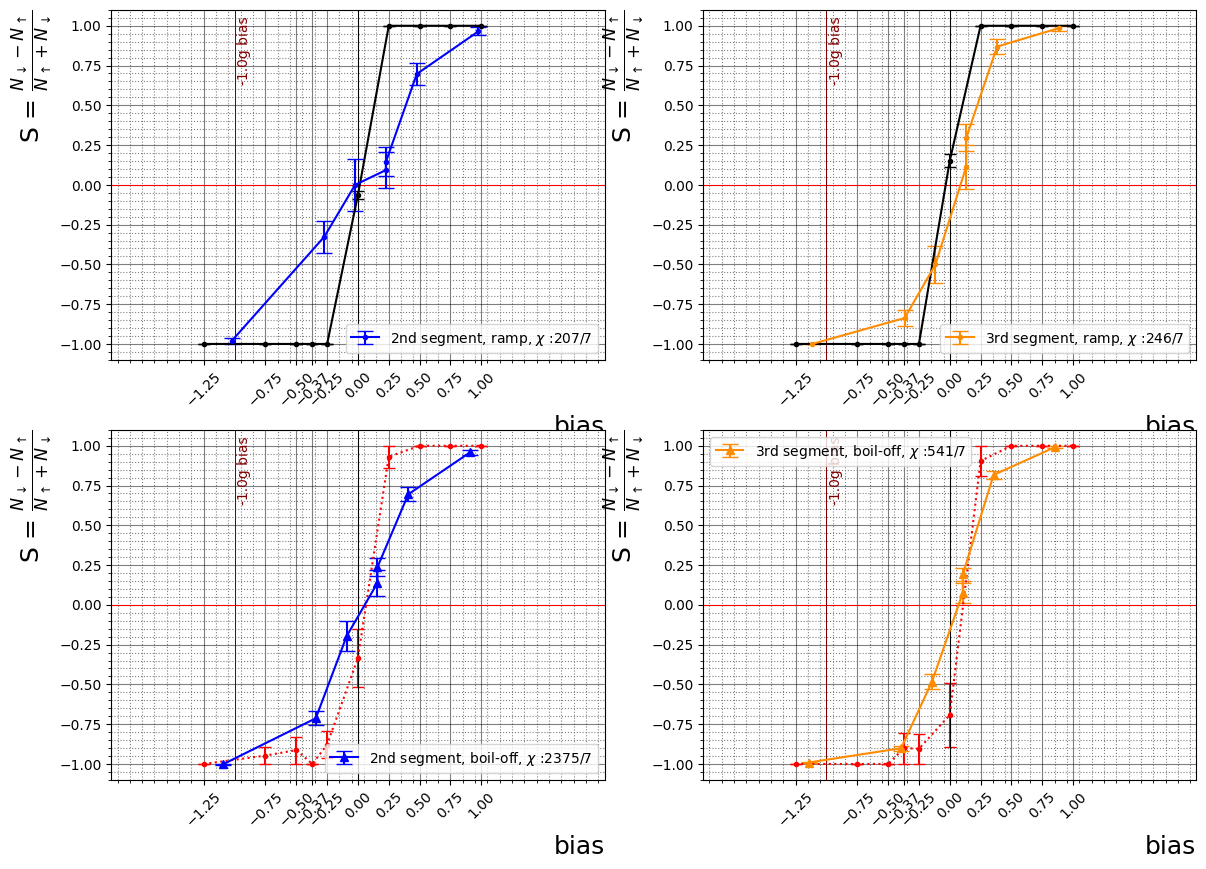

In [19]:
idx = np.argsort(biases)
plt.figure(1, figsize = (14,10))

plt.subplot(2,2,1)
#plt.suptitle("2nd segment")
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], simulation_2nd(biases[idx]), dsimulation_2nd(biases[idx]),marker = ".", linestyle = "-", markersize = 6,color = "black", capsize = 4)
# DATASET 2025
mask = df_onlyramps['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment2'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment2'][mask],
             df_onlyramps['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  2, simulation_2nd):.0f}/{mask.sum()}")

plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,2)
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], simulation_3rd(biases[idx]), dsimulation_3rd(biases[idx]),  marker = ".", linestyle = "-", markersize = 6, color = "black", capsize = 4)
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment3'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment3'][mask],
             df_onlyramps['err_segment3'][mask], 
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  3, simulation_3rd):.0f}/{mask.sum()}")
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()


plt.subplot(2,2,3)
# SIMULATION
plt.errorbar(biases[idx], simulation_2nd_boiloff(biases[idx]), dsimulation_2nd_boiloff(biases[idx]) , marker = ".", linestyle = "dotted", markersize = 6,color = "red", capsize = 4)
#dataset with boil-off
mask = df_onlywait['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment2'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment2'][mask],
             df_onlywait['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff):.0f}/{mask.sum()}")
plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,4)
# SIMULATION
plt.errorbar(biases[idx], simulation_3rd_boiloff(biases[idx]), dsimulation_3rd_boiloff(biases[idx]), marker = ".", linestyle = "dotted", markersize = 6,  color = "red",capsize = 4)
#dataset with boil-off
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment3'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment3'][mask],
             df_onlywait['err_segment3'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff):.0f}/{mask.sum()}")


plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.savefig(f"{best_sim.replace('/','')}_Scurve.png", bbox_inches = 'tight')

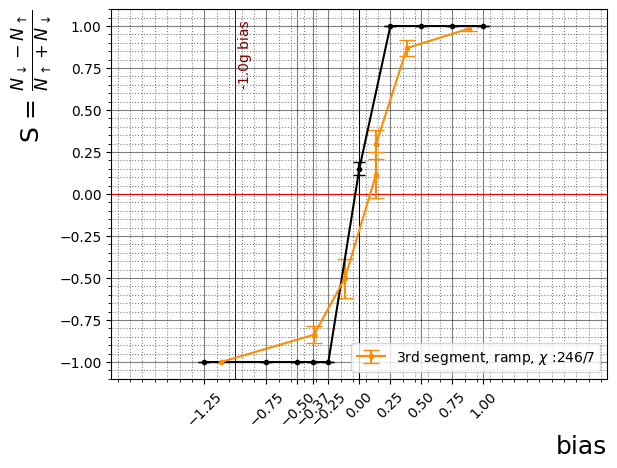

In [20]:
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], simulation_3rd(biases[idx]), dsimulation_3rd(biases[idx]) ,marker = ".", linestyle = "-", markersize = 6, color = "black", capsize = 4)
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment3'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment3'][mask],
             df_onlyramps['err_segment3'][mask], 
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  3, simulation_3rd):.0f}/{mask.sum()}")
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.savefig(f"{best_sim.replace('/','')}_Scurve_seg3.png", bbox_inches = 'tight')

# Compute the Metric, Chiquare between data and simulation

In [21]:
from scipy.interpolate import CubicSpline
idx = np.argsort(biases)

# Spline of simulation
simulation_2nd = CubicSpline(biases[idx], A1[idx])

simulation_3rd = CubicSpline(biases[idx], A2[idx])

simulation_2nd_boiloff = CubicSpline(biases[idx], A1b[idx])

simulation_3rd_boiloff = CubicSpline(biases[idx], A2b[idx])

print(compute_segment_chisq(df_onlyramps, 2, simulation_2nd))
print(compute_segment_chisq(df_onlyramps, 3, simulation_3rd))

print(compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff))
print(compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff))

207.07177629061928
245.89734948596907
2375.195467973533
540.6809823544179
